In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta

import folium

## Activity Differences Check

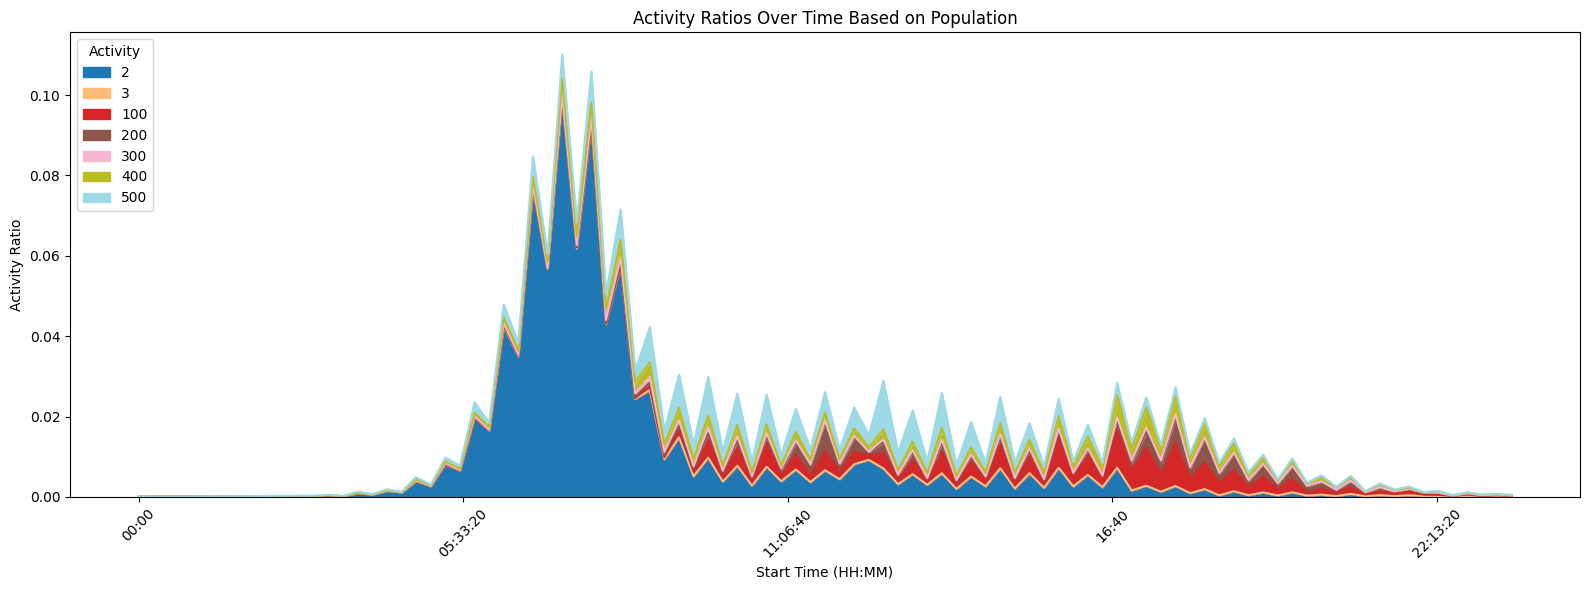

In [4]:
def visualize_activity_ratios(file_path):
    # Load the data
    data = pd.read_csv(file_path, names=['id', 'age', 'gender', 'occupation', 'starttime', 'duration', 'activity', 'lon', 'lat', 'citycode'], header=None, skiprows=1)
    
    # Convert 'starttime' from seconds to a readable time format (HH:MM)
    data['starttime_formatted'] = data['starttime'].apply(lambda x: (datetime.min + timedelta(seconds=x)).time())
    
    # Group the data by 'starttime_formatted' and 'activity' and count unique 'id's to consider population
    grouped_data = data.groupby(['starttime_formatted', 'activity'])['id'].nunique().unstack(fill_value=0)
    
    # Calculate the ratio of activities based on the unique 'id' counts (population)
    population_per_time = len(data['id'].unique())  # Total unique individuals per starttime
    activity_ratios = grouped_data.div(population_per_time, axis=0)[[2,3,100,200,300,400,500]]
    # print(activity_ratios[[2,3,100,200,300,400,500]])
    
    # Plotting with ordered activities and a diverse color palette
    plt.figure(figsize=(16, 6))
    activity_ratios.plot(kind='area', stacked=True, ax=plt.gca(), colormap='tab20')
    plt.title('Activity Ratios Over Time Based on Population')
    plt.xlabel('Start Time (HH:MM)')
    plt.ylabel('Activity Ratio')
    plt.xticks(rotation=45)
    plt.legend(title='Activity', loc='upper left')
    plt.tight_layout()
    
    # Show the plot
    plt.show()

# Example usage
file_path = '/mnt/large/data/PseudoPFLOW/activity/13/person_13101_labor.csv'  # Replace with your actual file path
visualize_activity_ratios(file_path)

In [5]:
def visualize_activity_ratios(file_path):
    # Load the data
    data = pd.read_csv(file_path, names=['id', 'age', 'gender', 'occupation', 'starttime', 'duration', 'activity', 'lon', 'lat', 'citycode'], header=None, skiprows=1)
    
    # Convert 'starttime' from seconds to a readable time format (HH:MM)
    data['starttime_formatted'] = data['starttime'].apply(lambda x: (datetime.min + timedelta(seconds=x)).time())
    
    # Duplicate 00:00 data for missing time slots between 00:15 and 02:45
    midnight_data = data[data['starttime_formatted'] == datetime.strptime("00:00", "%H:%M").time()]
    for minutes in range(15, 166, 15):  # Loop from 00:15 to 02:45 in 15-minute intervals
        fill_time = (datetime.min + timedelta(minutes=minutes)).time()
        fill_data = midnight_data.copy()
        fill_data['starttime_formatted'] = fill_time
        data = pd.concat([data, fill_data])
    
    # Group the data by 'starttime_formatted' and 'activity' and count unique 'id's
    grouped_data = data.groupby(['starttime_formatted', 'activity'])['id'].nunique().unstack(fill_value=0)
    
    # Calculate the ratio of activities based on the unique 'id' counts (population)
    population_per_time = len(data['id'].unique())  # Total unique individuals per starttime
    activity_ratios = grouped_data.div(population_per_time, axis=0)[[2,3, 100,200,300,400, 500]]
    
    # Plotting with ordered activities and a diverse color palette
    plt.figure(figsize=(16, 6))
    activity_ratios.plot(kind='area', stacked=True, ax=plt.gca(), colormap='tab20')
    plt.title('Activity Ratios Over Time Based on Population')
    plt.xlabel('Start Time (HH:MM)')
    plt.ylabel('Activity Ratio')
    plt.xticks(rotation=45)
    plt.legend(title='Activity', loc='upper left')
    plt.tight_layout()
    
    # Show the plot
    plt.show()

# You can use this improved function by passing the file path as an argument.


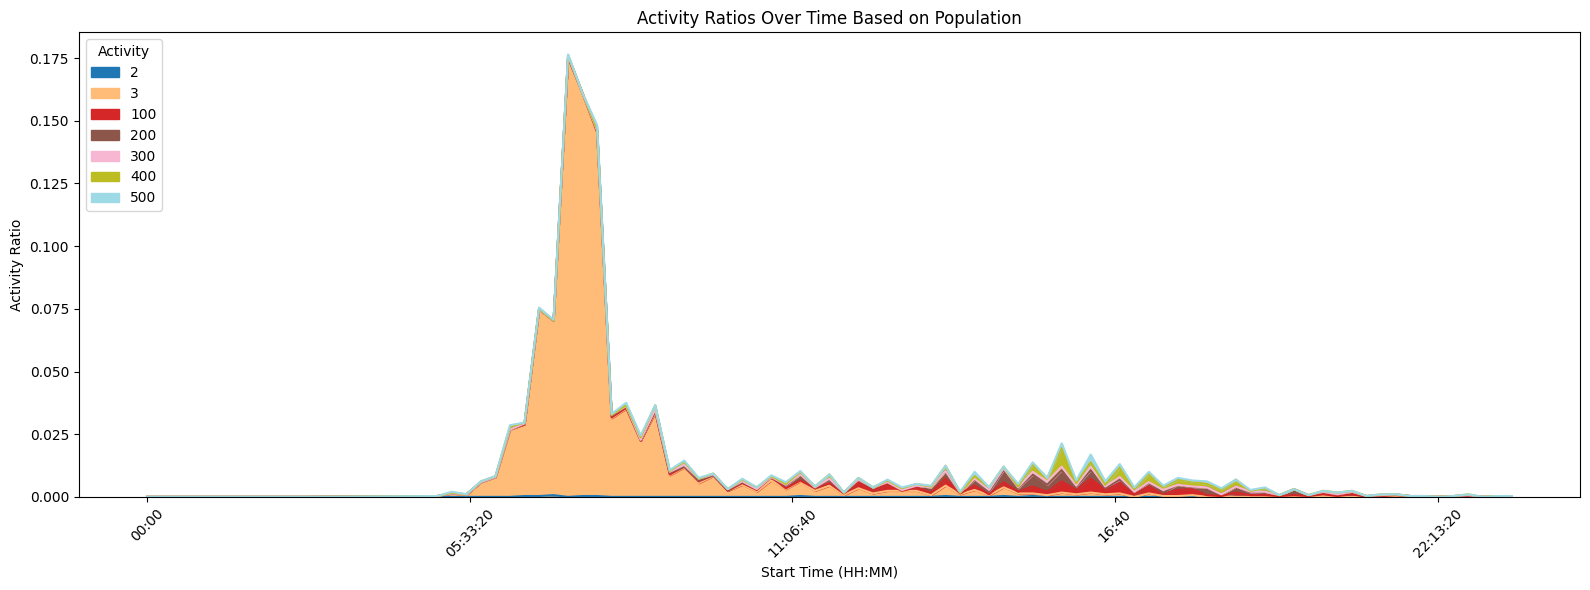

In [6]:
file_path = '/mnt/large/data/PseudoPFLOW/activity/1/person_01101_student.csv'
visualize_activity_ratios(file_path)

In [43]:
def calculate_activity_ratios(file_path):
    data = pd.read_csv(file_path, names=['id', 'age', 'gender', 'occupation', 'starttime', 'duration', 'activity', 'lon', 'lat', 'citycode'], header=None, skiprows=1)
    data['starttime_formatted'] = data['starttime'].apply(lambda x: (datetime.min + timedelta(seconds=x)).time())
    
    midnight_data = data[data['starttime_formatted'] == datetime.strptime("00:00", "%H:%M").time()]
    for minutes in range(15, 166, 15):
        fill_time = (datetime.min + timedelta(minutes=minutes)).time()
        fill_data = midnight_data.copy()
        fill_data['starttime_formatted'] = fill_time
        data = pd.concat([data, fill_data])
        
    grouped_data = data.groupby(['starttime_formatted', 'activity'])['id'].nunique().unstack(fill_value=0)
    population_per_time = len(data['id'].unique())
    activity_ratios = grouped_data.div(population_per_time, axis=0)[[2,3,100,200,300,400,500]]
    
    return activity_ratios


In [44]:
file_path1 = '/mnt/large/data/PseudoPFLOW/activity/13/person_13101_labor.csv'  # Replace with the actual path of the first file
file_path2 = '/mnt/large/data/PseudoPFLOW/activity/13_2018/person_13101_labor.csv'  # Replace with the actual path of the second file

activity_ratios_1 = calculate_activity_ratios(file_path1)
activity_ratios_2 = calculate_activity_ratios(file_path2)

# Calculate the differences
differences = activity_ratios_1 - activity_ratios_2


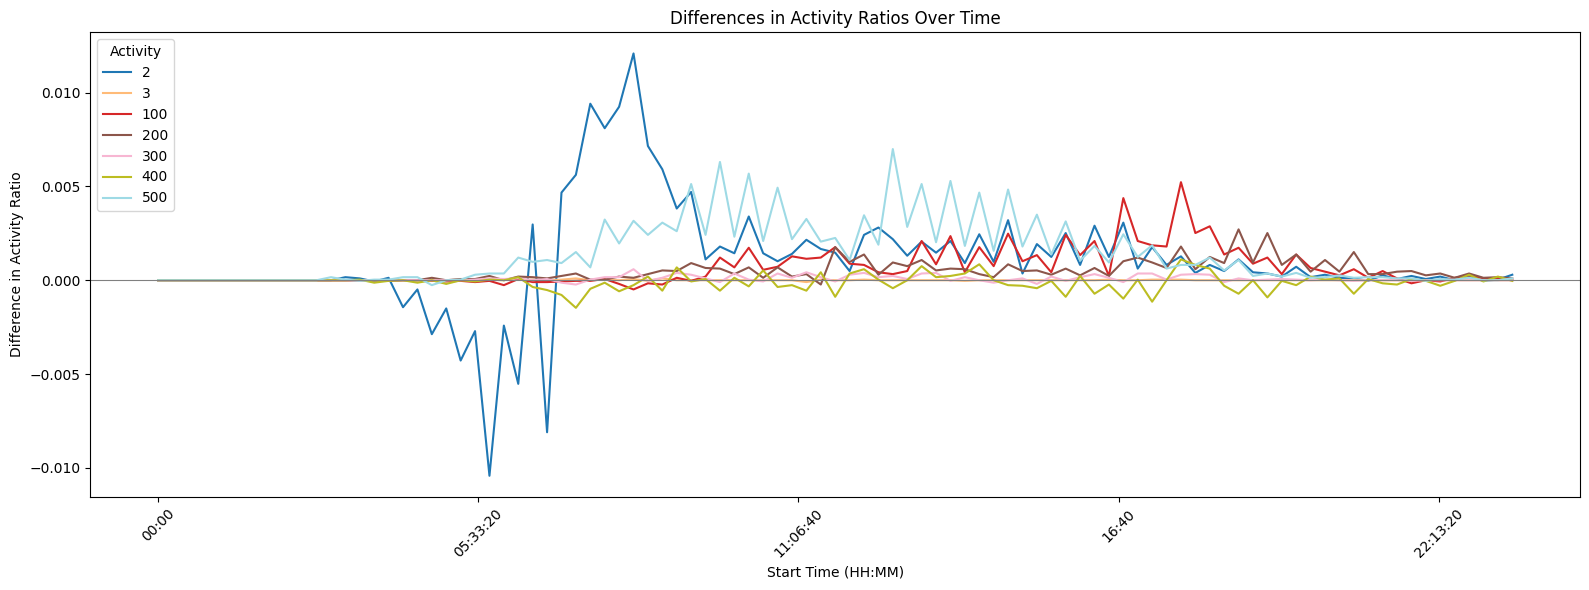

In [46]:
plt.figure(figsize=(16, 6))
differences.plot(kind='line', ax=plt.gca(), colormap='tab20')  # Changed from 'area' to 'line'
plt.title('Differences in Activity Ratios Over Time')
plt.xlabel('Start Time (HH:MM)')
plt.ylabel('Difference in Activity Ratio')
plt.axhline(0, color='gray', lw=0.8)  # Adds a horizontal line at y=0 for reference
plt.xticks(rotation=45)
plt.legend(title='Activity', loc='upper left')
plt.tight_layout()
plt.show()



## Outing Ratio and Average Trips

In [24]:
pop_root = '/Users/pang/Data/PseudoPFLOW/agent/person_12101.csv' 
act_root = '/Users/pang/Data/PseudoPFLOW/Activity1.2/12/activity_12101.csv'

pop = pd.read_csv(pop_root)
act = pd.read_csv(act_root, names=['pid', 'age', 'gender', 'occupation', 'starttime', 'duration', 'purpose', 'lon', 'lat', 'zcode'])

len(pop), len(act.groupby('pid'))

(200343, 190959)

In [30]:
root = '/Users/pang/Data/PseudoPFLOW/'
for pref in os.listdir(f'{root}Activity1.2/'):
    out, trips, pop = 0, 0, 0
    if pref == '.DS_Store':
        continue
    for filename in os.listdir(f'{root}Activity1.2/{pref}/'):
        df = pd.read_csv(f'{root}Activity1.2/{pref}/{filename}', names=['pid', 'age', 'gender', 'occupation', 'starttime', 'duration', 'purpose', 'lon', 'lat', 'zcode'])
        grouped_df = df.groupby("pid")
        df_pop = pd.read_csv(f'{root}agent/{pref}/person_{filename[9:]}')
        pop += len(df_pop)
        for pid, person in grouped_df:
            if len(person) == 1 and person['duration'].iloc[0] == 86400:
                continue
            trips += len(person)
            out += 1
    print(f'Pref: {pref} Outing ratio: {out / pop} Average Trips: {trips / pop} Pop: {pop}')

Pref: 03 Outing ratio: 0.7634872510881948 Average Trips: 2.9062619337163866
Pref: 04 Outing ratio: 0.7557351245685252 Average Trips: 2.8846002330379945
Pref: 32 Outing ratio: 0.7623788753594702 Average Trips: 2.9068862882540736
Pref: 35 Outing ratio: 0.749055488485288 Average Trips: 2.8661859718481764
Pref: 34 Outing ratio: 0.7604048467672293 Average Trips: 2.9021845067146943
Pref: 33 Outing ratio: 0.7586629079276161 Average Trips: 2.8945656617625866
Pref: 05 Outing ratio: 0.7459184914780695 Average Trips: 2.8486330628580965
Pref: 02 Outing ratio: 0.7518640308498782 Average Trips: 2.8693415532367843
Pref: 20 Outing ratio: 0.7700931287675604 Average Trips: 2.9310123223034714
Pref: 18 Outing ratio: 0.7723401736025721 Average Trips: 2.9382033656154487
Pref: 27 Outing ratio: 0.7542670042503783 Average Trips: 2.8810639811188556
Pref: 11 Outing ratio: 0.7624134609435952 Average Trips: 2.9106514948221434
Pref: 29 Outing ratio: 0.7457721468086479 Average Trips: 2.851475603662864
Pref: 16 Outin

In [15]:
root = '/mnt/large/data/PseudoPFLOW/'
for pref in os.listdir(f'{root}activity_merge2/'):
    out, trips, pop = 0, 0, 0
    if pref == '.DS_Store':
        continue
    for filename in os.listdir(f'{root}activity_merge2/{pref}/'):
        df = pd.read_csv(f'{root}activity_merge2/{pref}/{filename}', names=['pid', 'age', 'gender', 'occupation', 'starttime', 'duration', 'purpose', 'lon', 'lat', 'zcode'])
        grouped_df = df.groupby("pid")
        # df_pop = pd.read_csv(f'{root}agent/{pref}/person_{filename[9:]}')
        pop += len(grouped_df)
        for pid, person in grouped_df:
            if len(person) == 1 and person['duration'].iloc[0] == 86400:
                continue
            trips += len(person)
            out += 1
    print(f'Pref: {pref} Outing ratio: {out / pop} Average Trips: {trips / pop} Pop: {pop}')

Pref: 13 Outing ratio: 0.6486207227945415 Average Trips: 2.0686182864535243
Pref: 1 Outing ratio: 0.7457627991015228 Average Trips: 2.3444407713653304
Pref: 36 Outing ratio: 0.617425849687916 Average Trips: 1.866320518509641
Pref: 14 Outing ratio: 0.642772719828285 Average Trips: 2.0386296795773298
Pref: 31 Outing ratio: 0.6381341450505199 Average Trips: 1.95522449323485
Pref: 37 Outing ratio: 0.6231421597835087 Average Trips: 1.9005630456777665
Pref: 34 Outing ratio: 0.6185262966157539 Average Trips: 1.8922420027965434
Pref: 40 Outing ratio: 0.621875020302217 Average Trips: 1.904614062977102
Pref: 26 Outing ratio: 0.621006923459582 Average Trips: 1.9048865842259541
Pref: 6 Outing ratio: 0.7530189435446177 Average Trips: 2.3779183305966614
Pref: 7 Outing ratio: 0.7565282384574992 Average Trips: 2.3877348806894494
Pref: 28 Outing ratio: 0.6126160177683672 Average Trips: 1.8684787165822498
Pref: 17 Outing ratio: 0.8600539235932702 Average Trips: 2.9661076740876426
Pref: 3 Outing ratio: 0

### out, trips, pop

In [13]:
out / pop, trips / pop

(0.7991595371845197, 3.058837071515299)

## Transport Mode

In [3]:
walk, bike, car, train = 0, 0, 0, 0

trip = pd.read_csv('C:\\large\\PseudoPFLOW\\trip\\16\\trip_16209.csv', names=['uid', 'starttime', 'olon', 'olat', 'dlon', 'dlat', 'mode', 'purpose', 'occupation'])
trip

,uid,starttime,olon,olat,dlon,dlat,mode,purpose,occupation
0,59209929,-1818,136.866951,36.677349,137.268583,36.671343,1,2,21
1,59209929,31648,137.268583,36.671343,136.866951,36.677349,3,1,21
2,59209933,0,136.868232,36.677855,136.868232,36.677855,0,1,21
3,59209934,28254,136.878976,36.666259,136.876236,36.659944,1,2,21
4,59209934,66509,136.876236,36.659944,136.878976,36.666259,3,1,21
...,...,...,...,...,...,...,...,...,...
50732,59239425,23664,136.846852,36.723663,136.875710,36.685907,1,3,12
50733,59239425,51564,136.875710,36.685907,136.846852,36.723663,1,1,12
50734,59239441,0,136.846852,36.723663,136.846852,36.723663,0,1,15
50735,59239446,26214,136.846234,36.723820,137.096186,36.725739,1,3,16


In [16]:
trip['mode'].value_counts()

mode
3    23849
0    10401
1    10232
2     5775
4      500
5       21
Name: count, dtype: int64

In [24]:
trip = pd.read_csv('/home/mdxuser/Data/PseudoPFLOW/trip/48/trip_13101.csv', names=['uid', 'starttime', 'olon', 'olat', 'dlon', 'dlat', 'mode', 'purpose', 'occupation'])
trip

,uid,starttime,olon,olat,dlon,dlat,mode,purpose,occupation
0,33922893,27780,139.741718,35.683095,139.740511,35.684103,3,2,21
1,33923090,14400,139.741318,35.682328,139.741961,35.681914,3,100,21
2,33923454,25980,139.738219,35.682536,139.738131,35.683931,3,2,21
3,33923803,0,139.747684,35.698592,139.747684,35.698592,0,1,21
4,33923981,25860,139.747392,35.698460,139.748769,35.699514,3,500,21
5,33924180,30000,139.745017,35.697618,139.745408,35.696167,3,400,21


In [32]:
trip['mode'].value_counts().values / len(trip)

array([0.53410591, 0.23591625, 0.21586975, 0.00725459, 0.0068535 ])

In [34]:
trip['mode'].value_counts()

mode
1    274320
0    121168
3    110872
5      3726
4      3520
Name: count, dtype: int64

In [37]:
trip[trip['mode']!=0]['mode'].value_counts() / len(trip[trip['mode']!=0])

mode
1    0.699015
3    0.282521
5    0.009494
4    0.008970
Name: count, dtype: float64

In [27]:
pop = len(trip.groupby('uid'))
pop

283052

In [28]:
stastic = trip
stastic.values = trip['mode'].value_counts().values / pop
stastic

<ipython-input-28-00e742703a8d>:2: UserWarning: Pandas doesn't allow columns to be created via a new attribute name - see https://pandas.pydata.org/pandas-docs/stable/indexing.html#attribute-access
  stastic.values = trip['mode'].value_counts().values / pop


AttributeError: can't set attribute

In [16]:
trip['mode'].value_counts()

mode
1    30553
6    23467
0    17361
3    14016
Name: count, dtype: int64

In [23]:
from haversine import haversine, Unit

In [24]:
def calculate_distance(row):
    origin = (row['olat'], row['olon'])
    destination = (row['dlat'], row['dlon'])
    return haversine(origin, destination, unit=Unit.KILOMETERS)

trip['distance'] = trip.apply(calculate_distance, axis=1)
trip

,uid,starttime,olon,olat,dlon,dlat,mode,purpose,occupation,distance
0,33922893,27780,139.741445,35.683175,139.796937,35.698165,6,2,21,5.281417
1,33922893,64920,139.796937,35.698165,139.741445,35.683175,6,1,21,5.281417
2,33922894,19980,139.738391,35.682707,139.767316,35.676852,6,2,21,2.692479
3,33922894,60540,139.767316,35.676852,139.738391,35.682707,6,1,21,2.692479
4,33922895,32760,139.741542,35.682479,139.789974,35.694266,6,100,21,4.566178
...,...,...,...,...,...,...,...,...,...,...
85392,33980632,25560,139.776835,35.699666,139.754883,35.699840,1,3,15,1.982359
85393,33980632,58800,139.754883,35.699840,139.770867,35.696084,1,300,15,1.502597
85394,33980632,63060,139.770867,35.696084,139.776835,35.699666,1,1,15,0.670135
85395,33980649,22680,139.777872,35.699204,139.741240,35.695346,1,3,15,3.335672


<Axes: >

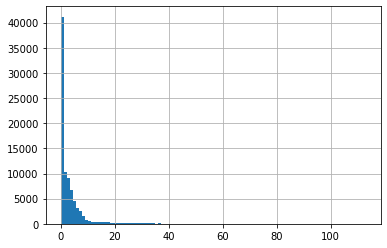

In [26]:
trip['distance'].hist(bins=100)

In [33]:
trip[(trip['distance']<1)&(trip['distance']>0)]#['mode'].hist()

,uid,starttime,olon,olat,dlon,dlat,mode,purpose,occupation,distance
8,33922899,26940,139.739443,35.682798,139.742393,35.687217,6,2,21,0.558957
9,33922899,63120,139.742393,35.687217,139.739443,35.682798,1,1,21,0.558957
21,33922910,38640,139.739956,35.682343,139.739240,35.687163,3,100,21,0.539847
22,33922910,42240,139.739240,35.687163,139.739956,35.682343,3,1,21,0.539847
25,33922915,29580,139.740188,35.682966,139.741348,35.689554,3,2,21,0.740007
...,...,...,...,...,...,...,...,...,...,...
85385,33980371,22260,139.766620,35.693002,139.768460,35.693486,1,3,12,0.174664
85386,33980371,54660,139.768460,35.693486,139.766620,35.693002,1,1,12,0.174664
85388,33980383,26940,139.768558,35.694277,139.768460,35.693486,1,3,12,0.088399
85389,33980383,56640,139.768460,35.693486,139.768558,35.694277,1,1,12,0.088399


## POI check

In [19]:
df = pd.read_csv("/home/mdxuser/Data/PseudoPFLOW/activity_merge3/16/activity_16201.csv", names=['pid', 'age', 'gender', 'occupation', 'starttime', 'duration', 'purpose', 'lon', 'lat', 'zcode'])
df

,pid,age,gender,occupation,starttime,duration,purpose,lon,lat,zcode
0,58427013,57,1,21,0,23400,1,137.225763,36.731524,16201
1,58427013,57,1,21,23400,2700,400,137.216225,36.703293,16201
2,58427013,57,1,21,26100,32400,2,137.234285,36.728026,16201
3,58427013,57,1,21,58500,27900,1,137.225763,36.731524,16201
4,58427014,51,1,21,0,24300,1,137.225706,36.730832,16201
...,...,...,...,...,...,...,...,...,...,...
985004,58832751,6,2,12,51300,35100,1,137.140060,36.627428,16201
985005,58832765,15,1,14,0,31500,1,137.139662,36.624408,16201
985006,58832766,6,2,12,0,27000,1,137.139662,36.624408,16201
985007,58832766,6,2,12,27000,28800,3,137.137224,36.611220,16201


In [20]:
check = df[df["purpose"].isin([100, 200])]
check

,pid,age,gender,occupation,starttime,duration,purpose,lon,lat,zcode
31,58427025,36,2,21,61200,15300,200,137.207127,36.670892,16201
59,58427039,58,1,21,72000,5400,200,137.263163,36.703222,16201
60,58427039,58,1,21,77400,9000,100,137.250933,36.692826,16201
89,58427058,52,1,21,39600,17100,100,137.179635,36.728057,16201
99,58427062,40,2,21,64800,900,100,137.177854,36.699412,16201
...,...,...,...,...,...,...,...,...,...,...
587597,58832738,35,1,21,43200,2700,200,136.903737,36.516618,16210
587616,58832754,57,1,21,41400,2700,200,137.214411,36.693348,16201
587622,58832757,73,2,21,51300,1800,100,137.127551,36.681611,16201
587650,58832773,56,2,21,54000,1800,100,137.178822,36.716601,16201


In [21]:
map_center = [df['lat'].mean(), df['lon'].mean()]

# Create a map
map = folium.Map(location=map_center, zoom_start=13)

# Add points
for index, row in check.iterrows():
    folium.Marker([row['lat'], row['lon']], popup=f'PID: {row["pid"]}').add_to(map)
    # print(index)
    if index >= 1000:
        break

# Show the map
map

# start time check

In [10]:
trip = pd.read_csv('C:\\large\\PseudoPFLOW\\trip\\16\\trip_16209.csv', names=['uid', 'starttime', 'olon', 'olat', 'dlon', 'dlat', 'mode', 'purpose', 'occupation'])
error_ids = trip[trip['starttime']<0]['uid'].unique()

trip[trip['uid'].isin(error_ids)]

,uid,starttime,olon,olat,dlon,dlat,mode,purpose,occupation
0,59209929,-1818,136.866951,36.677349,137.268583,36.671343,1,2,21
1,59209929,31648,137.268583,36.671343,136.866951,36.677349,3,1,21
9009,59219154,-10242,136.886448,36.623474,137.450021,36.820252,1,2,21
9010,59219154,32868,137.450021,36.820252,136.886448,36.623474,1,1,21
12576,59222878,-5664,136.879960,36.678596,137.391447,36.780781,1,2,21
12577,59222878,32130,137.391447,36.780781,136.879960,36.678596,1,1,21
22584,59233327,-4254,136.881024,36.666742,136.550464,36.514438,1,2,21
22585,59233327,46158,136.550464,36.514438,136.881024,36.666742,1,1,21
24176,59234958,-5466,136.900178,36.658854,136.467957,36.403113,1,2,21
24177,59234958,41323,136.467957,36.403113,136.462781,36.408025,3,200,21


In [16]:
act = trip = pd.read_csv('C:\\Data\\PseudoPFLOW\\activity_merge3\\16\\activity_16209.csv', names=['uid', 'age', 'gender', 'occupation', 'starttime', 'duration', 'purpose', 'olon', 'olat', 'zcode'])
act

,uid,age,gender,occupation,starttime,duration,purpose,olon,olat,zcode
0,59209929,34,1,21,0,18900,1,136.866951,36.677349,16209
1,59209929,34,1,21,18900,16200,2,137.268583,36.671343,16201
2,59209929,34,1,21,35100,51300,1,136.866951,36.677349,16209
3,59209933,48,1,21,0,86400,1,136.868232,36.677855,16209
4,59209934,34,1,21,0,28800,1,136.878976,36.666259,16209
...,...,...,...,...,...,...,...,...,...,...
70154,59239425,11,1,12,54900,31500,1,136.846852,36.723663,16209
70155,59239441,18,2,15,0,42300,1,136.846852,36.723663,16209
70156,59239446,18,2,16,0,41400,1,136.846234,36.723820,16209
70157,59239446,18,2,16,41400,16200,3,137.096186,36.725739,16211


In [18]:
act[act['uid'].isin(error_ids)]

,uid,age,gender,occupation,starttime,duration,purpose,olon,olat,zcode
0,59209929,34,1,21,0,18900,1,136.866951,36.677349,16209
1,59209929,34,1,21,18900,16200,2,137.268583,36.671343,16201
2,59209929,34,1,21,35100,51300,1,136.866951,36.677349,16209
13240,59219154,36,1,21,0,23400,1,136.886448,36.623474,16209
13241,59219154,36,1,21,23400,43200,2,137.450021,36.820252,16204
13242,59219154,36,1,21,66600,19800,1,136.886448,36.623474,16209
18483,59222878,43,1,21,0,22500,1,136.879960,36.678596,16209
18484,59222878,43,1,21,22500,37800,2,137.391447,36.780781,16204
18485,59222878,43,1,21,60300,26100,1,136.879960,36.678596,16209
33059,59233327,56,1,21,0,17100,1,136.881024,36.666742,16209


## ID check

In [93]:
traj = pd.read_csv("C:/large/PseudoPFLOW/trajectory/0/trajectory_16209.csv", names=['pid', 'ut', 'timestamp', 'lon', 'lat', 'mode', 'gender', 'occupation', 'linkid'])
act = pd.read_csv("C:/Data/PseudoPFLOW/activity_merge3/0/activity_16209.csv", names=['pid', 'age', 'gender', 'occupation', 'starttime', 'duration', 'purpose', 'lon', 'lat', 'zcode'])
trip = pd.read_csv("C:/large/PseudoPFLOW/trip/0/trip_16209.csv", names=['pid', 'starttime', 'olon', 'olat', 'dlon', 'dlat', 'mode', 'purpose', 'occupation'])

In [95]:
traj

,pid,ut,timestamp,lon,lat,mode,gender,occupation,linkid
0,59209929,1443644100000,2015-10-01 05:15:00,136.866941,36.676897,6,2,WORKER,NaN
1,59209929,1443644112295,2015-10-01 05:15:12,136.866216,36.677138,6,2,WORKER,NaN
2,59209929,1443644117202,2015-10-01 05:15:17,136.866304,36.677380,6,2,WORKER,NaN
3,59209929,1443644122946,2015-10-01 05:15:22,136.866453,36.677650,6,2,WORKER,NaN
4,59209929,1443644122946,2015-10-01 05:15:22,136.866453,36.677650,6,2,WORKER,NaN
...,...,...,...,...,...,...,...,...,...
66738,59210573,1443682484273,2015-10-01 15:54:44,136.955686,36.580205,1,2,WORKER,3521148.0
66739,59210573,1443682499808,2015-10-01 15:54:59,136.955899,36.580397,1,2,WORKER,3519642.0
66740,59210573,1443682589520,2015-10-01 15:56:29,136.957123,36.581505,1,2,WORKER,3519640.0
66741,59210573,1443682626196,2015-10-01 15:57:06,136.957698,36.581113,1,2,WORKER,3519727.0


In [97]:
len(traj.pid.unique()), len(act.pid.unique()), len(trip.pid.unique())

(337, 337, 337)

In [99]:
diff = list(set(act.pid.unique()) - set(trip.pid.unique()))

act[act["pid"].isin(diff)]

,pid,age,gender,occupation,starttime,duration,purpose,lon,lat,zcode


In [69]:
len(traj.pid.unique()), len(act.pid.unique()), len(trip.pid.unique())

(11183, 28260, 19248)